# Homework 4

Note: Our group, Kymanni and I, spent 4 hours working together on March 23rd at 6:30 PM. We're not exactly sure what's going on with our other groupmate, Jaiden. (RS).

## 4.3-1

Use the substitution method to show the asymptotic solution specified.

### 4.3-1 (d)

$T(n)=2T(n/2+17)+n$ has solution $T(n)=O(n\lg n)$.

#### My proof:
Since
$$
\left(\frac n2+17\right)-34=\frac{n-34}{2},
$$
the natural guess is
$$
T(n)\le c(n-34)\lg(n-34)-dn,
$$
for sufficiently large $n$; the we determined the $-dn$ was necesary after trying without it (positive lower-order terms were still left). Now, assume the inductive hypothesis holds for the recursive input $n/2+17$. Then,
$$
T(n)\le 2\left(c\left(\left(\frac n2+17\right)-34\right)\lg\left(\left(\frac n2+17\right)-34\right)-d\left(\frac n2+17\right)\right)+n.
$$
Since
$$
\left(\frac n2+17\right)-34=\frac{n-34}{2},
$$
this becomes
$$
T(n)\le 2\left(c\left(\frac{n-34}{2}\right)\lg\left(\frac{n-34}{2}\right)-d\left(\frac n2+17\right)\right)+n.
$$
Simplifying,
$$
T(n)\le c(n-34)\lg\left(\frac{n-34}{2}\right)-d(n+34)+n.
$$
Use $\lg(x/2)=\lg x-1$:
$$
T(n)\le c(n-34)(\lg(n-34)-1)-d(n+34)+n.
$$
Expanding,
$$
T(n)\le c(n-34)\lg(n-34)-c(n-34)-d(n+34)+n.
$$
We want this to be at most
$$
c(n-34)\lg(n-34)-dn.
$$
So it is enough that
$$
c(n-34)+34d-n\ge 0.
$$
That is,
$$
(c-1)n+34(d-c)\ge 0.
$$
This works for all sufficiently large $n$ if we choose, for example, $c\ge 1$ and $d\ge c$. Therefore, the inductive step closes, and after choosing constants large enough for the base cases, we get
$$
T(n)=O(n\lg n).
$$

SymPy check for the shifted inductive guess:
target - recursive expression = c*n - 34*c + 34*d - n

Sample values of T(n)/(n lg n) for T(n)=2T(n/2+17)+n:
n= 40, ratio=0.1973
n= 60, ratio=0.9085
n= 80, ratio=0.7553
n=100, ratio=1.1830
n=120, ratio=1.0400
n=140, ratio=1.6051
...
n=700, ratio=1.3667
n=720, ratio=1.3412
n=740, ratio=1.3296
n=760, ratio=1.3021
n=780, ratio=1.2813
n=800, ratio=1.2565


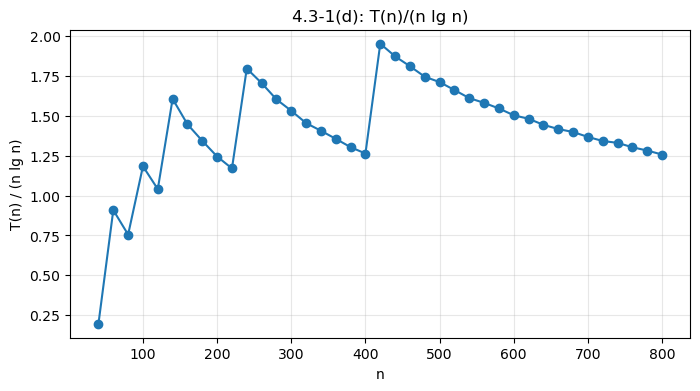

In [22]:
# Check with SymPy and Matplotlib.
import math
import sympy as sp
import matplotlib.pyplot as plt

n, c, d = sp.symbols("n c d", positive=True)
expr = (
    2 * (c * ((n / 2 + 17) - 34) * sp.log((n / 2 + 17) - 34, 2) - d * (n / 2 + 17))
    + n
)
expr = expr.subs(sp.log((n - 34) / 2, 2), sp.log(n - 34, 2) - 1)
expr = sp.expand(expr)
target = c * (n - 34) * sp.log(n - 34, 2) - d * n
print("SymPy check for the shifted inductive guess:")
print("target - recursive expression =", sp.simplify(target - expr))

values = {}
for m in range(1, 801):
    if m < 40:
        values[m] = 1.0
    else:
        values[m] = 2 * values[m // 2 + 17] + m

ns = list(range(40, 801, 20))
ratios = [values[m] / (m * math.log2(m)) for m in ns]
print("\nSample values of T(n)/(n lg n) for T(n)=2T(n/2+17)+n:")
for m, r in zip(ns[:6], ratios[:6]):
    print(f"n={m:3d}, ratio={r:.4f}")
print("...")
for m, r in zip(ns[-6:], ratios[-6:]):
    print(f"n={m:3d}, ratio={r:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.3-1(d): T(n)/(n lg n)")
plt.xlabel("n")
plt.ylabel("T(n) / (n lg n)")
plt.grid(True, alpha=0.3)
plt.show()

#### SymPy / Matplotlib check:

- SymPy confirms that the shifted inductive step differs from the target by
  $$
  (c-1)n+34(d-c),
  $$
  which is exactly the condition used in the proof.
- The plot checks the actual asymptotic claim numerically by showing that $T(n)/(n\lg n)$ stays bounded.

### 4.3-1 (f)

$T(n)=4T(n/2)+\Theta(n)$ has solution $T(n)=\Theta(n^2)$.

#### My proof:
Since the driving term is $\Theta(n)$, there are constants $a,b>0$ such that, for large $n$,
$$
a n\le \Theta(n)\le b n.
$$
So $an$ is a lower bound on the nonrecursive part, and $bn$ is an upper bound. We use the upper bound for the $O(n^2)$ proof and the lower bound for the $\Omega(n^2)$ proof. To show the upper bound, we use the stronger guess
$$
T(n)\le cn^2-dn.
$$
Assuming it holds for the recursive input $n/2$,
$$
T(n)\le 4\left(c\left(\frac n2\right)^2-d\left(\frac n2\right)\right)+bn
=cn^2-2dn+bn.
$$
For this to be at most $cn^2-dn$, we just need
$$
-2dn+bn\le -dn,
$$
which is the same as $b\le d$. So if we choose $d\ge b$, then
$$
T(n)\le cn^2-dn,
$$
and therefore
$$
T(n)=O(n^2).
$$

To show the lower bound, we can use the simpler guess
$$
T(n)\ge en^2
$$
for some constant $e>0$. Then,
$$
T(n)\ge 4e\left(\frac n2\right)^2+an
=en^2+an
\ge en^2.
$$
So
$$
T(n)=\Omega(n^2).
$$

Since both bounds match asymptotically,
$$
T(n)=\Theta(n^2).
$$

Upper-bound algebra for 4.3-1(f): b*n + c*n**2 - 2*d*n
Difference from c*n^2 - d*n: b*n - d*n
Naive guess leftover for 4.3-2: n
Sample values of T(n)/n^2 for T(n)=4T(n/2)+n:
n=   2, ratio=1.500000
n=   4, ratio=1.750000
n=   8, ratio=1.875000
n=  16, ratio=1.937500
n=  32, ratio=1.968750
n=  64, ratio=1.984375
n= 128, ratio=1.992188
n= 256, ratio=1.996094
n= 512, ratio=1.998047
n=1024, ratio=1.999023


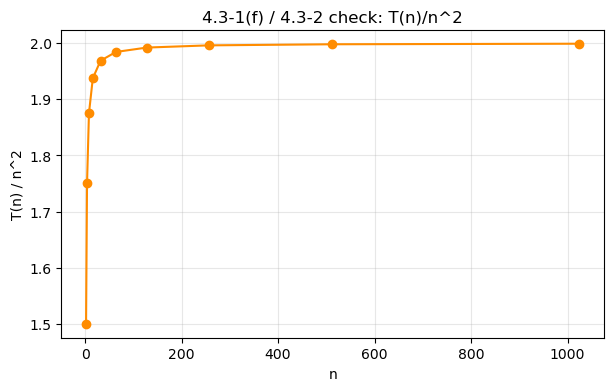

In [23]:
# Check with SymPy and Matplotlib.
import sympy as sp
import matplotlib.pyplot as plt

n, b, c, d = sp.symbols("n b c d", positive=True)
upper_expr = sp.expand(4 * (c * (n / 2) ** 2 - d * (n / 2)) + b * n)
print("Upper-bound algebra for 4.3-1(f):", upper_expr)
print("Difference from c*n^2 - d*n:", sp.expand(upper_expr - (c * n**2 - d * n)))
fail_expr = sp.expand(4 * c * (n / 2) ** 2 + n - c * n**2)
print("Naive guess leftover for 4.3-2:", fail_expr)

sizes = [2**k for k in range(1, 11)]
prev = 1.0
values = []
for m in sizes:
    prev = 4 * prev + m
    values.append(prev)
ratios = [v / (m * m) for m, v in zip(sizes, values)]
print("Sample values of T(n)/n^2 for T(n)=4T(n/2)+n:")
for m, r in zip(sizes, ratios):
    print(f"n={m:4d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(sizes, ratios, marker="o", color="darkorange")
plt.title("4.3-1(f) / 4.3-2 check: T(n)/n^2")
plt.xlabel("n")
plt.ylabel("T(n) / n^2")
plt.grid(True, alpha=0.3)
plt.show()

From the output:

- SymPy shows the upper-bound step becomes $cn^2+n(b-d)$, so choosing $d\ge b$ makes the induction work.
- For 4.3-2, SymPy leaves a leftover $+n$, which is exactly why the naive guess $T(n)\le cn^2$ fails.
- The graph of $T(n)/n^2$ staying near a constant supports the final answer $\Theta(n^2)$.

## 4.3-2

$T(n)=4T(n/2)+n$ turns out to have solution $T(n)=\Theta(n^2)$.

#### Why the direct guess fails:
If we try the substitution guess
$$
T(n)\le cn^2,
$$
then, substitution gives
$$
T(n)\le 4c\left(\frac n2\right)^2+n
=cn^2+n.
$$
But that does not get us back to $cn^2$, because the extra $+n$ is still there. In other words,
$$
cn^2+n\le cn^2
$$
is false for positive $n$. So the direct substitution proof does not close. That is exactly the same reason as why the stronger form $cn^2-dn$ was needed in the previous problem.

## 4.5-1

Use the master method to give tight asymptotic bounds.

### 4.5-1 (b)

$T(n)=2T(n/4)+\sqrt n$.

#### My answer:
$$
T(n)=\Theta(\sqrt n\,\lg n).
$$

#### My explanation:
Here, $a=2$ and $b=4$, so
$$
n^{\log_b a}=n^{\log_4 2}=n^{1/2}=\sqrt n.
$$
Also,
$$
f(n)=\sqrt n=\Theta\!\left(n^{\log_4 2}\lg^0 n\right).
$$
So this falls under case 2 of the Master Theorem with $k=0$. Case 2 implies
$$
T(n)=\Theta\!\left(n^{\log_4 2}\lg^{0+1} n\right)
=\Theta(\sqrt n\,\lg n).
$$

#### SymPy / Matplotlib check:

SymPy check for the watershed function:
log_4(2) = 1/2
n^(1/2) - sqrt(n) = 0

Sample values of T(n)/(sqrt(n) lg n):
n=    4, ratio=1.000000
n=   16, ratio=0.750000
n=   64, ratio=0.666667
n=  256, ratio=0.625000
n= 1024, ratio=0.600000
n= 4096, ratio=0.583333
n=16384, ratio=0.571429
n=65536, ratio=0.562500


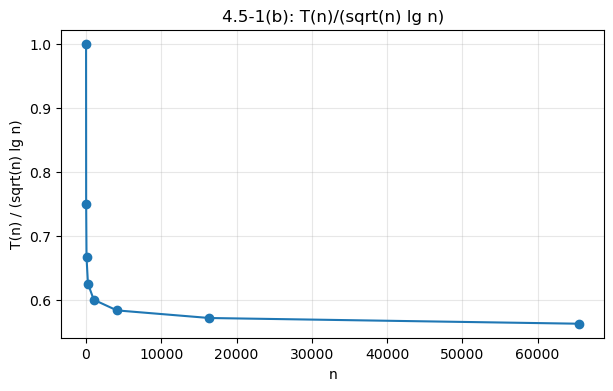

In [24]:
# Check with SymPy and Matplotlib.
import math
import sympy as sp
import matplotlib.pyplot as plt

n = sp.symbols("n", positive=True)
print("SymPy check for the watershed function:")
print("log_4(2) =", sp.simplify(sp.log(2, 4)))
print("n^(1/2) - sqrt(n) =", sp.simplify(n ** sp.Rational(1, 2) - sp.sqrt(n)))

ns = [4**k for k in range(1, 9)]
prev = 1.0
values = []
for m in ns:
    prev = 2 * prev + math.sqrt(m)
    values.append(prev)
ratios = [v / (math.sqrt(m) * math.log2(m)) for m, v in zip(ns, values)]
print("\nSample values of T(n)/(sqrt(n) lg n):")
for m, r in zip(ns, ratios):
    print(f"n={m:5d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.5-1(b): T(n)/(sqrt(n) lg n)")
plt.xlabel("n")
plt.ylabel("T(n) / (sqrt(n) lg n)")
plt.grid(True, alpha=0.3)
plt.show()

SymPy confirms that the watershed exponent is $1/2$, and the plot shows the normalized ratio staying bounded, which matches $\Theta(\sqrt n\,\lg n)$.

### 4.5-1 (c)

$T(n)=2T(n/4)+\sqrt n\,\lg^2 n$.

#### My answer:
$$
T(n)=\Theta(\sqrt n\,\lg^3 n).
$$

#### My explanation:
Again, $a=2$ and $b=4$, so
$$
n^{\log_b a}=n^{\log_4 2}=\sqrt n.
$$
Now,
$$
f(n)=\sqrt n\,\lg^2 n=\Theta\!\left(n^{\log_4 2}\lg^2 n\right).
$$
So this is case 2 of the Master Theorem with $k=2$. By case 2,
$$
T(n)=\Theta\!\left(n^{\log_4 2}\lg^{2+1} n\right)
=\Theta(\sqrt n\,\lg^3 n).
$$

#### SymPy / Matplotlib check:

SymPy check that the driving term is n^(log_4 2) lg^2 n:
0

Sample values of T(n)/(sqrt(n) lg^3 n):
n=    4, ratio=0.625000
n=   16, ratio=0.328125
n=   64, ratio=0.263889
n=  256, ratio=0.236328
n= 1024, ratio=0.221000
n= 4096, ratio=0.211227
n=16384, ratio=0.204446
n=65536, ratio=0.199463


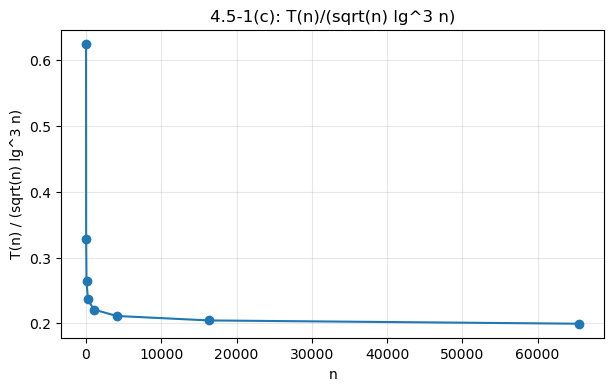

In [25]:
# Check with SymPy and Matplotlib.
import math
import sympy as sp
import matplotlib.pyplot as plt

n = sp.symbols("n", positive=True)
expr1 = n ** sp.log(2, 4) * sp.log(n, 2) ** 2
expr2 = sp.sqrt(n) * sp.log(n, 2) ** 2
print("SymPy check that the driving term is n^(log_4 2) lg^2 n:")
print(sp.simplify(expr1 - expr2))

ns = [4**k for k in range(1, 9)]
prev = 1.0
values = []
for m in ns:
    prev = 2 * prev + math.sqrt(m) * (math.log2(m) ** 2)
    values.append(prev)
ratios = [v / (math.sqrt(m) * (math.log2(m) ** 3)) for m, v in zip(ns, values)]
print("\nSample values of T(n)/(sqrt(n) lg^3 n):")
for m, r in zip(ns, ratios):
    print(f"n={m:5d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.5-1(c): T(n)/(sqrt(n) lg^3 n)")
plt.xlabel("n")
plt.ylabel("T(n) / (sqrt(n) lg^3 n)")
plt.grid(True, alpha=0.3)
plt.show()

SymPy confirms the form of the driving term, and the ratio plot stays bounded, which is what we expect for $\Theta(\sqrt n\,\lg^3 n)$.

### 4.5-1 (d)

$T(n)=2T(n/4)+n$.

#### My answer:
$$
T(n)=\Theta(n).
$$

#### My explanation:
Here, $a=2$ and $b=4$, so
$$
n^{\log_b a}=n^{\log_4 2}=\sqrt n.
$$
Also,
$$
f(n)=n=\Omega\!\left(n^{\log_4 2+\epsilon}\right)
$$
with $\epsilon=\tfrac12>0$, since $\log_4 2+\epsilon=\tfrac12+\tfrac12=1$. Now, check the regularity condition:
$$
af(n/b)=2f(n/4)=2\left(\frac n4\right)=\frac n2\le cn
$$
if we choose $0<c=\tfrac12<1$. So case 3 of the Master Theorem applies, and case 3 implies
$$
T(n)=\Theta(f(n))=\Theta(n).
$$

#### SymPy / Matplotlib check:

SymPy regularity check:
2*(n/4) simplifies to n/2
(2*(n/4))/n simplifies to 1/2

Sample values of T(n)/n:
n=    4, ratio=1.500000
n=   16, ratio=1.750000
n=   64, ratio=1.875000
n=  256, ratio=1.937500
n= 1024, ratio=1.968750
n= 4096, ratio=1.984375
n=16384, ratio=1.992188
n=65536, ratio=1.996094


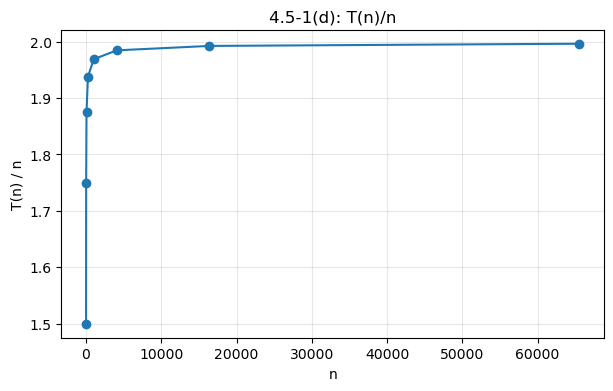

In [26]:
# Check with SymPy and Matplotlib.
import sympy as sp
import matplotlib.pyplot as plt

n = sp.symbols("n", positive=True)
print("SymPy regularity check:")
print("2*(n/4) simplifies to", sp.simplify(2 * (n / 4)))
print("(2*(n/4))/n simplifies to", sp.simplify((2 * (n / 4)) / n))

ns = [4**k for k in range(1, 9)]
prev = 1.0
values = []
for m in ns:
    prev = 2 * prev + m
    values.append(prev)
ratios = [v / m for m, v in zip(ns, values)]
print("\nSample values of T(n)/n:")
for m, r in zip(ns, ratios):
    print(f"n={m:5d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.5-1(d): T(n)/n")
plt.xlabel("n")
plt.ylabel("T(n) / n")
plt.grid(True, alpha=0.3)
plt.show()

SymPy shows the regularity ratio is $1/2$, and the graph of $T(n)/n$ staying bounded matches $\Theta(n)$.

### 4.5-1 (e)

$T(n)=2T(n/4)+n^2$.

#### My answer:
$$
T(n)=\Theta(n^2).
$$

#### My explanation:
Here, $a=2$ and $b=4$, so
$$
n^{\log_b a}=n^{\log_4 2}=\sqrt n.
$$
Also,
$$
f(n)=n^2=\Omega\!\left(n^{\log_4 2+\epsilon}\right)
$$
with $\epsilon=\tfrac32>0$, since $\log_4 2+\epsilon=\tfrac12+\tfrac32=2$. Now, check the regularity condition:
$$
af(n/b)=2f(n/4)=2\left(\frac n4\right)^2=\frac{n^2}{8}\le cn^2
$$
if we choose $0<c=\tfrac18<1$. So case 3 of the Master Theorem applies, and case 3 implies
$$
T(n)=\Theta(f(n))=\Theta(n^2).
$$

#### SymPy / Matplotlib check:

SymPy regularity check:
2*(n/4)^2 simplifies to n**2/8
(2*(n/4)^2)/n^2 simplifies to 1/8

Sample values of T(n)/n^2:
n=    4, ratio=1.125000
n=   16, ratio=1.140625
n=   64, ratio=1.142578
n=  256, ratio=1.142822
n= 1024, ratio=1.142853
n= 4096, ratio=1.142857
n=16384, ratio=1.142857
n=65536, ratio=1.142857


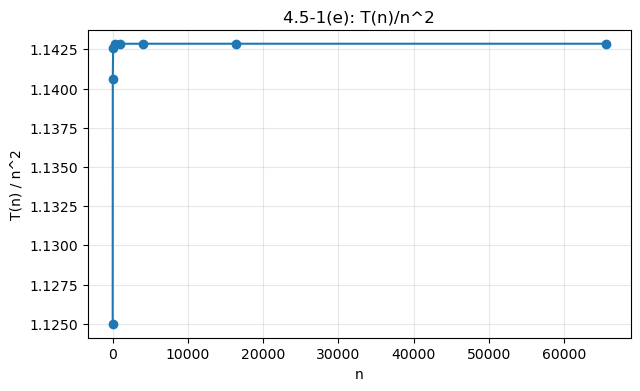

In [27]:
# Check with SymPy and Matplotlib.
import sympy as sp
import matplotlib.pyplot as plt

n = sp.symbols("n", positive=True)
print("SymPy regularity check:")
print("2*(n/4)^2 simplifies to", sp.simplify(2 * (n / 4) ** 2))
print("(2*(n/4)^2)/n^2 simplifies to", sp.simplify((2 * (n / 4) ** 2) / n**2))

ns = [4**k for k in range(1, 9)]
prev = 1.0
values = []
for m in ns:
    prev = 2 * prev + m * m
    values.append(prev)
ratios = [v / (m * m) for m, v in zip(ns, values)]
print("\nSample values of T(n)/n^2:")
for m, r in zip(ns, ratios):
    print(f"n={m:5d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.5-1(e): T(n)/n^2")
plt.xlabel("n")
plt.ylabel("T(n) / n^2")
plt.grid(True, alpha=0.3)
plt.show()

SymPy shows the regularity ratio is $1/8$, and the normalized plot supports $\Theta(n^2)$.

### 4.5-3

$T(n)=T(n/2)+\Theta(1)$.

#### My answer:
$$
T(n)=\Theta(\lg n).
$$

#### My explanation:
Here, $a=1$ and $b=2$, so
$$
n^{\log_b a}=n^{\log_2 1}=n^0=1.
$$
Also,
$$
f(n)=\Theta(1)=\Theta\!\left(n^{\log_2 1}\lg^0 n\right).
$$
So this is case 2 of the Master Theorem with $k=0$. Therefore, case 2 implies
$$
T(n)=\Theta\!\left(n^{\log_2 1}\lg^{0+1} n\right)=\Theta(\lg n).
$$

#### SymPy / Matplotlib check:

SymPy check for the watershed exponent:
log_2(1) = 0

Sample values of T(n)/lg n:
n=    2, ratio=2.000000
n=    4, ratio=1.500000
n=    8, ratio=1.333333
n=   16, ratio=1.250000
n=   32, ratio=1.200000
n=   64, ratio=1.166667
n=  128, ratio=1.142857
n=  256, ratio=1.125000
n=  512, ratio=1.111111
n= 1024, ratio=1.100000
n= 2048, ratio=1.090909


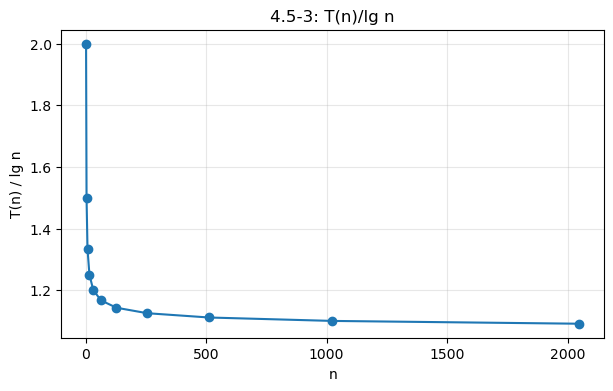

In [28]:
# Check with SymPy and Matplotlib.
import math
import sympy as sp
import matplotlib.pyplot as plt

print("SymPy check for the watershed exponent:")
print("log_2(1) =", sp.simplify(sp.log(1, 2)))

ns = [2**k for k in range(1, 12)]
prev = 1.0
values = []
for _ in ns:
    prev = prev + 1
    values.append(prev)
ratios = [v / math.log2(m) for m, v in zip(ns, values)]
print("\nSample values of T(n)/lg n:")
for m, r in zip(ns, ratios):
    print(f"n={m:5d}, ratio={r:.6f}")

plt.figure(figsize=(7, 4))
plt.plot(ns, ratios, marker="o")
plt.title("4.5-3: T(n)/lg n")
plt.xlabel("n")
plt.ylabel("T(n) / lg n")
plt.grid(True, alpha=0.3)
plt.show()

SymPy confirms the watershed exponent is $0$, and the ratio plot staying bounded matches $\Theta(\lg n)$.